In [ ]:
%pip install egglog graphviz

## First Attempt: `consists_of` Relation

Note: In this demo, for simplicity, we assume all WireVecs have fixed length 2. A full approach would need to handle variable-length WireVecs by either customizing primitives or adding iterative rules to mimic loops.

In [22]:
from __future__ import annotations
import egglog


class Wire(egglog.Expr):
    @classmethod
    def const(cls, val: egglog.i64Like) -> Wire: ...

    @classmethod
    def var(cls, id: egglog.i64Like) -> Wire: ...

    # bit-level operation examples
    def __and__(self, other: Wire) -> Wire: ...
    def __or__(self, other: Wire) -> Wire: ...
    def __invert__(self) -> Wire: ...


class WireVec(egglog.Expr):
    @classmethod
    def var(cls, name: egglog.StringLike) -> WireVec: ...

    # arithmetic operation examples
    def __add__(self, other: WireVec) -> WireVec: ...
    def __mul__(self, other: WireVec) -> WireVec: ...

    # extract
    def __getitem__(self, idx: egglog.i64Like) -> Wire: ...


# define consists_of relation
@egglog.function
def consists_of(wv: WireVec, vec: egglog.Vec[Wire]) -> egglog.Unit: ...

A WireVec has underlying Wires w1 and w2 can be represented as:

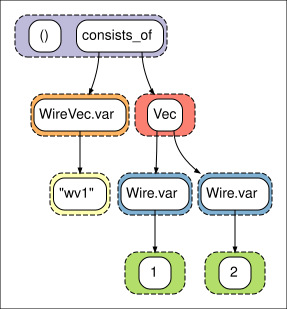

In [23]:
egraph = egglog.EGraph()
w1 = egraph.let("w1", Wire.var(1))
w2 = egraph.let("w2", Wire.var(2))
wv1 = egraph.let("wv1", WireVec.var("wv1"))
egraph.register(consists_of(wv1, egglog.Vec(w1, w2)))

egraph.display(graphviz=True)

Another example of two WireVecs' sum:

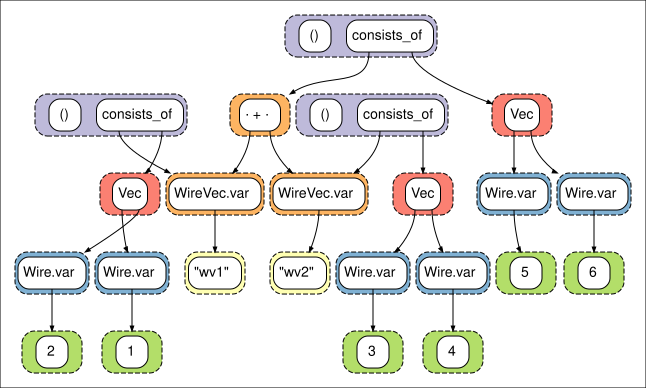

In [24]:
egraph = egglog.EGraph()
w1 = egraph.let("w1", Wire.var(1))
w2 = egraph.let("w2", Wire.var(2))
wv1 = egraph.let("wv1", WireVec.var("wv1"))
egraph.register(consists_of(wv1, egglog.Vec(w1, w2)))
w3 = egraph.let("w3", Wire.var(3))
w4 = egraph.let("w4", Wire.var(4))
wv2 = egraph.let("wv2", WireVec.var("wv2"))
egraph.register(consists_of(wv2, egglog.Vec(w3, w4)))
w5 = egraph.let("w5", Wire.var(5))
w6 = egraph.let("w6", Wire.var(6))
wv3 = egraph.let("wv3", wv1 + wv2)
egraph.register(consists_of(wv3, egglog.Vec(w5, w6)))

egraph.display(graphviz=True)

This approach, however, needs to (1) explicitly handle multiple `consists_of` relations over the same WireVec, namely resolving wire conflicts:

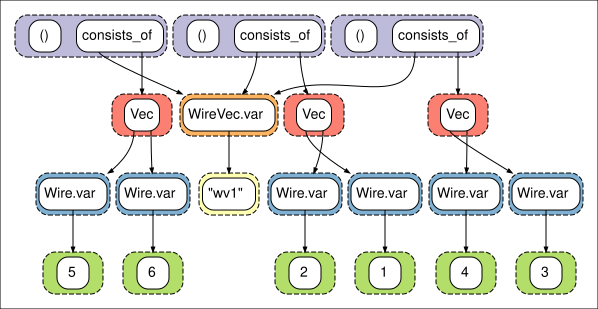

In [25]:
egraph = egglog.EGraph()
w1 = egraph.let("w1", Wire.var(1))
w2 = egraph.let("w2", Wire.var(2))
wv1 = egraph.let("wv1", WireVec.var("wv1"))
egraph.register(consists_of(wv1, egglog.Vec(w1, w2)))
w3 = egraph.let("w3", Wire.var(3))
w4 = egraph.let("w4", Wire.var(4))
egraph.register(consists_of(wv1, egglog.Vec(w3, w4)))
w5 = egraph.let("w5", Wire.var(5))
w6 = egraph.let("w6", Wire.var(6))
egraph.register(consists_of(wv1, egglog.Vec(w5, w6)))

egraph.display(graphviz=True)

And (2) handle multiple WireVecs that may share underlying Wires:

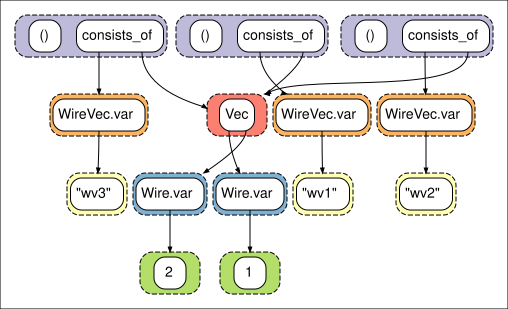

In [26]:
egraph = egglog.EGraph()
w1 = egraph.let("w1", Wire.var(1))
w2 = egraph.let("w2", Wire.var(2))
wv1 = egraph.let("wv1", WireVec.var("wv1"))
egraph.register(consists_of(wv1, egglog.Vec(w1, w2)))
wv2 = egraph.let("wv2", WireVec.var("wv2"))
egraph.register(consists_of(wv2, egglog.Vec(w1, w2)))
wv3 = egraph.let("wv3", WireVec.var("wv3"))
egraph.register(consists_of(wv3, egglog.Vec(w1, w2)))

egraph.display(graphviz=True)

This requires two kinds of rules, which leads to inefficiency because each pair of WireVecs or Vec[Wire]s is matched separately: $O(n^2)$.

In [27]:
wv1, wv2 = egglog.vars_("wv1 wv2", WireVec)
w1, w2, w3, w4 = egglog.vars_("w1 w2 w3 w4", Wire)
vec = egglog.var("vec", egglog.Vec[Wire])

rules = egglog.ruleset(
    # if a WireVec consists of two Vec[Wire]s, Vec[Wire]s should be unioned element-wise
    egglog.rule(
        consists_of(wv1, egglog.Vec[Wire](w1, w2)),
        consists_of(wv1, egglog.Vec[Wire](w3, w4))
    ).then(
        egglog.union(w1).with_(w3),
        egglog.union(w2).with_(w4)
    ),

    # if two WireVecs consist of the same Vec[Wire], they are equal
    egglog.rule(
        consists_of(wv1, vec),
        consists_of(wv2, vec)
    ).then(egglog.union(wv1).with_(wv2))
)

## Second Attempt: `Vec[Wire]` as Nodes

Let's simplify the representation by treating Vec[Wire] as a constructor of WireVec.

In [28]:
from __future__ import annotations
import egglog


class Wire(egglog.Expr):
    @classmethod
    def const(cls, val: egglog.i64Like) -> Wire: ...

    @classmethod
    def var(cls, id: egglog.i64Like) -> Wire: ...

    # bit-level operation examples
    def __and__(self, other: Wire) -> Wire: ...
    def __or__(self, other: Wire) -> Wire: ...
    def __invert__(self) -> Wire: ...


class WireVec(egglog.Expr):
    def __init__(self, wires: egglog.Vec[Wire]): ...

    @classmethod
    def var(cls, name: egglog.StringLike) -> WireVec: ...

    # arithmetic operation examples
    def __add__(self, other: WireVec) -> WireVec: ...
    def __mul__(self, other: WireVec) -> WireVec: ...

    # extract
    def __getitem__(self, idx: egglog.i64Like) -> Wire: ...

A WireVec has underlying Wires w1 and w2 can be represented as:

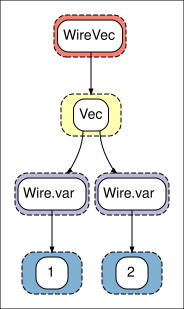

In [29]:
egraph = egglog.EGraph()
wv1 = egraph.let("wv1", WireVec(egglog.Vec[Wire](Wire.var(1), Wire.var(2))))

egraph.display(graphviz=True)

Another example of two WireVecs' sum:

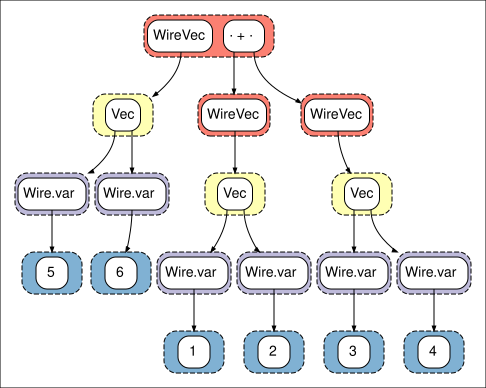

In [30]:
egraph = egglog.EGraph()
wv1 = egraph.let("wv1", WireVec(egglog.Vec[Wire](Wire.var(1), Wire.var(2))))
wv2 = egraph.let("wv2", WireVec(egglog.Vec[Wire](Wire.var(3), Wire.var(4))))
wv3 = egraph.let("wv3", wv1 + wv2)
egraph.register(egglog.union(wv3).with_(WireVec(egglog.Vec[Wire](Wire.var(5), Wire.var(6)))))

egraph.display(graphviz=True)

The good news is that problem (1) is naturally resolved, as there does not exist multiple WireVecs sharing the same Vec[Wire] node. It is guaranteed by egraph's invariant. However, problem (2) still exists, as a WireVec (class) can still consist of multiple Vec[Wire]s.

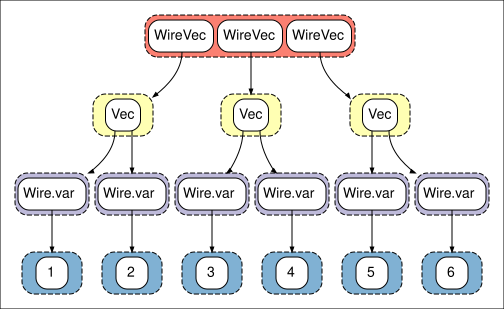

In [31]:
egraph = egglog.EGraph()
wv1 = egraph.let("wv1", WireVec(egglog.Vec[Wire](Wire.var(1), Wire.var(2))))
wv2 = egraph.let("wv2", WireVec(egglog.Vec[Wire](Wire.var(3), Wire.var(4))))
wv3 = egraph.let("wv3", WireVec(egglog.Vec[Wire](Wire.var(5), Wire.var(6))))
egraph.register(egglog.union(wv1).with_(wv2))
egraph.register(egglog.union(wv1).with_(wv3))

egraph.display(graphviz=True)

It is natural that if two WireVecs are unified, their underlying Wires should also be unified. Thus, we need the following rule to resolve conflicts:

In [32]:
vec1, vec2 = egglog.vars_("vec1 vec2", egglog.Vec[Wire])

rules = egglog.ruleset(
    # if two WireVecs are equal, their underlying Vec[Wire]s should be unioned element-wise
    egglog.rule(egglog.eq(WireVec(vec1)).to(WireVec(vec2))).then(
        egglog.union(vec1[0]).with_(vec2[0]),
        egglog.union(vec1[1]).with_(vec2[1])
    )
)

This is still $O(n^2)$ in the worst case, but intuitively, it should be more efficient if we can aggregate Vec[Wire]s under the same WireVec first and then resolve conflicts together and achieve $O(n)$ complexity.